10 rekordów od końca: 

                    Start time              Update time              Create time   Max  Min  Score                 End time
14135  2026-03-17 19:00:00.000  2026-03-17 20:07:50.744  2026-03-17 19:32:21.941  93.0  0.0    7.0  2026-03-17 19:59:59.999
14136  2026-03-17 20:00:00.000  2026-03-17 21:04:07.081  2026-03-17 20:44:52.381  98.0  0.0   27.0  2026-03-17 20:59:59.999
14137  2026-03-17 21:00:00.000  2026-03-17 23:55:03.819  2026-03-17 21:04:08.081  98.0  0.0   16.0  2026-03-17 21:59:59.999
14138  2026-03-17 23:00:00.000  2026-03-18 00:00:04.694  2026-03-17 23:55:03.924   0.0  0.0    0.0  2026-03-17 23:59:59.999
14139  2026-03-18 00:00:00.000  2026-03-18 00:00:04.781  2026-03-18 00:00:04.781   0.0  0.0    0.0  2026-03-18 00:00:04.764

Zakres wartości: od 0.0 do 100.0 

Wartości none:

                    Start time              Update time              Create time  Max  Min  Score                 End time
11418  2025-08-01 23:07:19.420  2025-08-01 23:07:19.532  

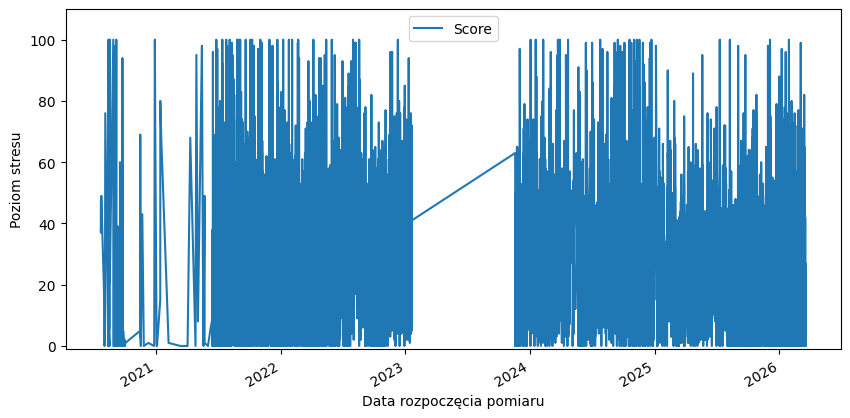

Wykres w przedziale od 07-01 do 09-01



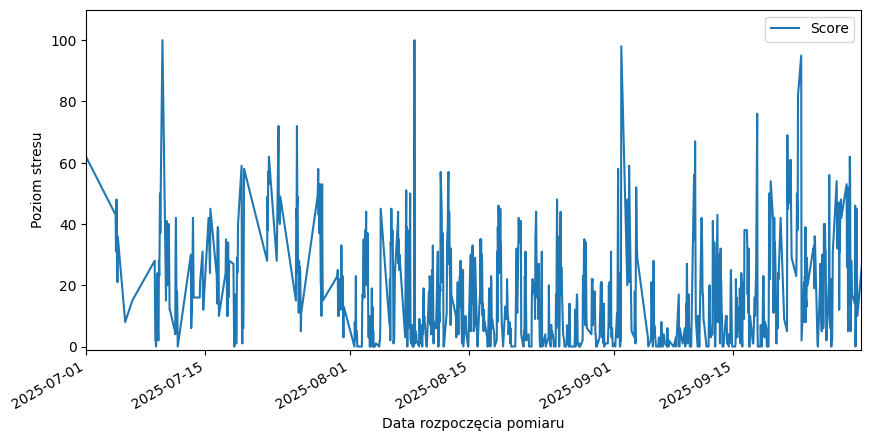

Zakres od 07-08 do 08-01



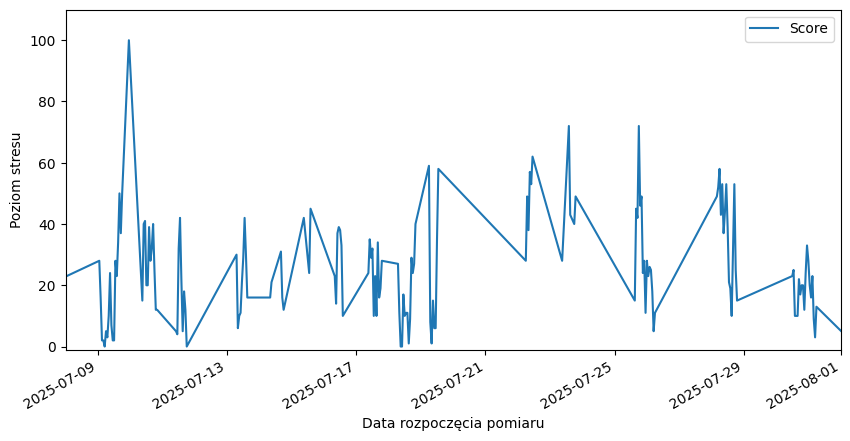

Dobry widok na zakres danych brakujących - od 01-19 19:00 do 11-18 11:00



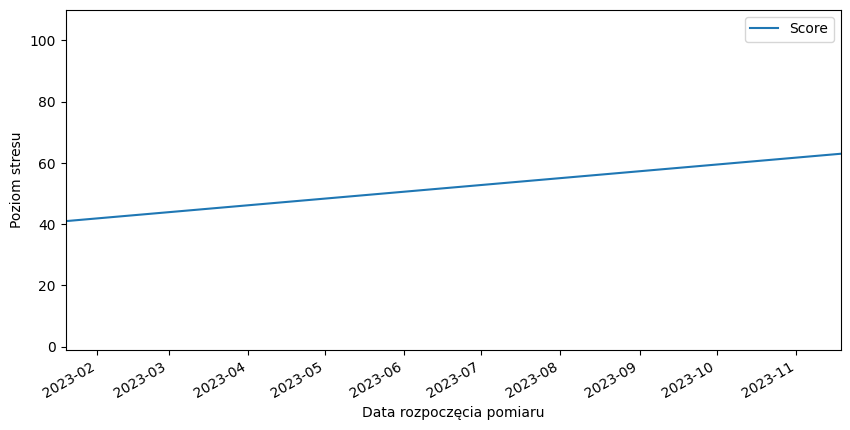

7 miesięczny przeskok

              Start time  Score
7025 2023-01-19 18:00:00     32
7028 2023-01-19 19:00:00     41
7076 2023-11-18 12:00:00     63
7062 2023-11-18 13:00:00     27
7073 2023-11-18 16:00:00      1
7091 2023-11-18 21:00:00      0
7080 2023-11-18 22:00:00      7
7041 2023-11-18 23:00:00      0


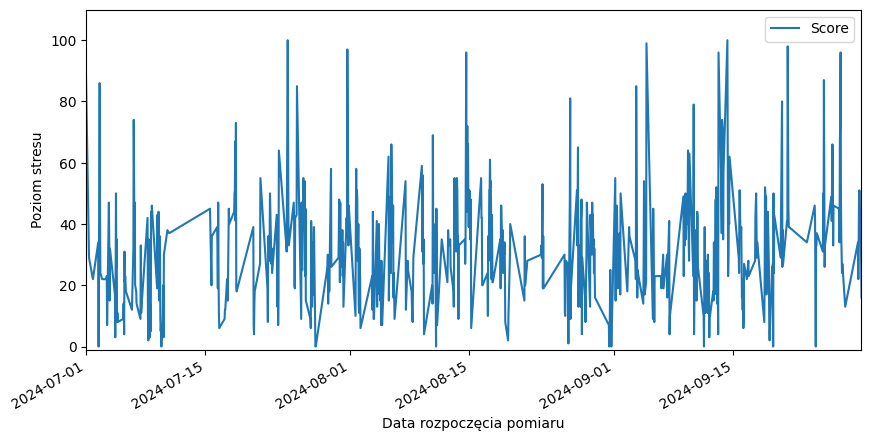

Średnia krocząca o oknie 365 dni



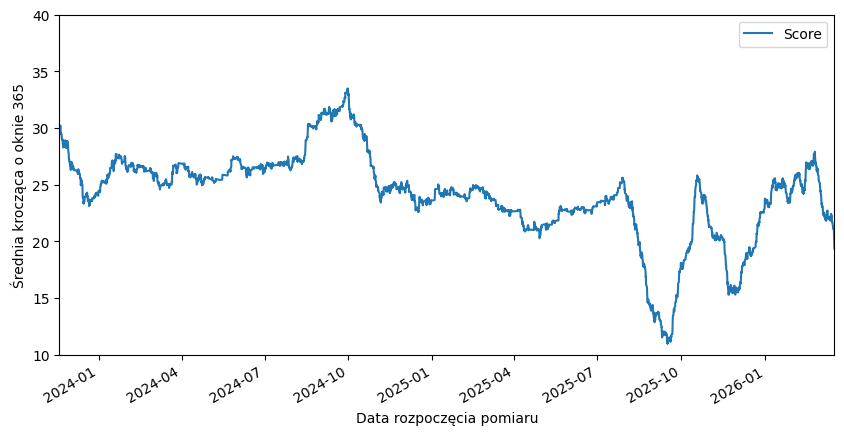

In [3]:
from pandas import read_csv, to_datetime, option_context

import matplotlib.pyplot as plt
from math import isnan 

from datetime import datetime

#Zapisanie pliku csv do dataframe

df = read_csv("data/samsung-health-stress-data.csv", header = 0, usecols=[1,6,7,8,9,10,16], names=["Start time", "Update time", "Create time","Max", "Min", "Score","End time"])  
with option_context('display.expand_frame_repr', False):
    print("10 rekordów od końca: \n")
    print(df.tail())

#Sprawdzanie zakresu wartości
min = df["Score"].min()
max = df["Score"].max()

print(f"\nZakres wartości: od {min} do {max} \n")

#Konwersja wyników stresu do liczb naturalnych

df=df.apply(lambda x: x.apply(lambda x: int(x) if not isnan(x) else -1) if x.name in ["Max", "Min", "Score"] else x)

#Sprawdzenie gdzie dane były Nan

wrong = df[df["Min"] == -1]
with option_context('display.expand_frame_repr', False):
    print("Wartości none:\n")
    print(wrong)

#Usuwanie tych rekordów gdzie było nan

df = df.drop(df[df["Min"] == -1].index)

#Zmiana dat na obiekty datetime

df = df.apply(lambda x: to_datetime(x, format="%Y-%m-%d %H:%M:%S.%f") if x.name in ["Start time", "Update time", "Create time", "End time"] else x) 

#Sortowanie danych po dacie

df = df.sort_values(by = 'Start time')

# Utworzenie wykresu

print("Wykres całego zakresu czasowego\n")
df.plot(x="Start time", y = "Score", figsize=(10,5))
plt.xlabel("Data rozpoczęcia pomiaru")
plt.ylabel("Poziom stresu")
plt.ylim(-1,110)
plt.show()

print("Wykres w przedziale od 07-01 do 09-01\n")
df.plot(x="Start time", y = "Score", figsize=(10,5))
plt.xlabel("Data rozpoczęcia pomiaru")
plt.ylabel("Poziom stresu")
plt.xlim('2025-07-01', '2025-09-30')
plt.ylim(-1,110)
plt.show()

print("Zakres od 07-08 do 08-01\n")
df.plot(x="Start time", y = "Score", figsize=(10,5))
plt.xlabel("Data rozpoczęcia pomiaru")
plt.ylabel("Poziom stresu")
plt.xlim('2025-07-08', '2025-08-01')
plt.ylim(-1,110)
plt.show()

print("Dobry widok na zakres danych brakujących - od 01-19 19:00 do 11-18 11:00\n")
df.plot(x="Start time", y = "Score", figsize=(10,5))
plt.xlabel("Data rozpoczęcia pomiaru")
plt.ylabel("Poziom stresu")
plt.xlim('2023-01-19 19:00', '2023-11-18 11:00')
plt.ylim(-1,110)
plt.show()
print("7 miesięczny przeskok\n")
na_range = df.loc[(df["Start time"] > '2023-01-19 17:00') & (df["Start time"] < '2023-11-19'), ['Start time', 'Score']]
print(na_range)

df.plot(x="Start time", y = "Score", figsize=(10,5))
plt.xlabel("Data rozpoczęcia pomiaru")
plt.ylabel("Poziom stresu")
plt.xlim('2024-07-01', '2024-09-30')
plt.ylim(-1,110)
plt.show()

print("Średnia krocząca o oknie 365 dni\n")
df_rmean = df.copy()
df_rmean["Score"] = df["Score"].rolling(365).mean()
df_rmean.plot(x="Start time", y = "Score", figsize=(10,5))
plt.ylabel("Średnia krocząca o oknie 365")
plt.xlabel("Data rozpoczęcia pomiaru")
plt.xlim('2023-11-19', '2026-03-18')
plt.ylim(10, 40)
plt.show()